# EXPERIMENT – 8
## Basic OpenGL Program Using Vertex and Fragment Shaders

**Name:** Ojas B A  
**USN:** 1RVU23CSE321  
**Course:** Computer Graphics and Virtual Reality

### Aim
To develop a basic OpenGL program using vertex and fragment shaders and render a colored triangle.

### 1. Setup

In [1]:
!pip -q install moderngl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 2.6 MB/s eta 0:00:00


### 2. Vertex and Fragment Shader Program

Each vertex is assigned a different color. The fragment shader displays the interpolated color across the triangle.

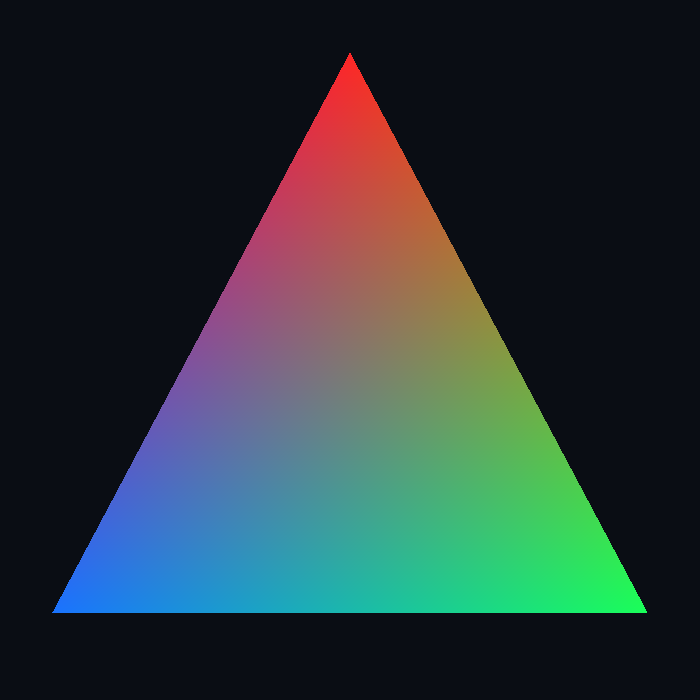

Vertex shader compiled successfully.
Fragment shader compiled successfully.
Colored triangle rendered successfully.


In [2]:
import moderngl
import numpy as np
from PIL import Image
from IPython.display import display

ctx = moderngl.create_standalone_context(backend='egl')

# Vertex Shader
vertex_shader = '''
#version 330

in vec2 in_position;
in vec3 in_color;
out vec3 vertex_color;

void main() {
    gl_Position = vec4(in_position, 0.0, 1.0);
    vertex_color = in_color;
}
'''

# Fragment Shader
fragment_shader = '''
#version 330

in vec3 vertex_color;
out vec4 fragColor;

void main() {
    fragColor = vec4(vertex_color, 1.0);
}
'''

program = ctx.program(
    vertex_shader=vertex_shader,
    fragment_shader=fragment_shader
)

# x, y, r, g, b
vertices = np.array([
     0.0,  0.85,   1.0, 0.15, 0.15,
    -0.85, -0.75,  0.10, 0.45, 1.00,
     0.85, -0.75,  0.10, 1.00, 0.35
], dtype='f4')

vbo = ctx.buffer(vertices.tobytes())
vao = ctx.vertex_array(
    program,
    [(vbo, '2f 3f', 'in_position', 'in_color')]
)

size = (700, 700)
fbo = ctx.simple_framebuffer(size)
fbo.use()
ctx.viewport = (0, 0, *size)

# Dark background for a cleaner visual output
ctx.clear(0.04, 0.05, 0.08, 1.0)
vao.render(moderngl.TRIANGLES)

data = fbo.read(components=3, alignment=1)
image = Image.frombytes('RGB', size, data)
image = image.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
image.save('experiment8_shader_output.png')

display(image)
print('Vertex shader compiled successfully.')
print('Fragment shader compiled successfully.')
print('Colored triangle rendered successfully.')

### Observation
The three vertices use different RGB colors. These colors are smoothly interpolated across the triangle by the graphics pipeline, producing a visible shaded gradient.

### Result
A basic OpenGL program using vertex and fragment shaders was implemented successfully. A multicolored triangle was rendered using interpolated vertex colors.